Step 1: Performing Exploratory Analysis...


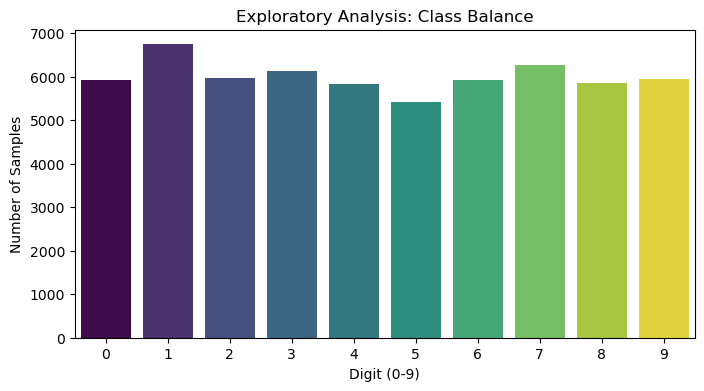

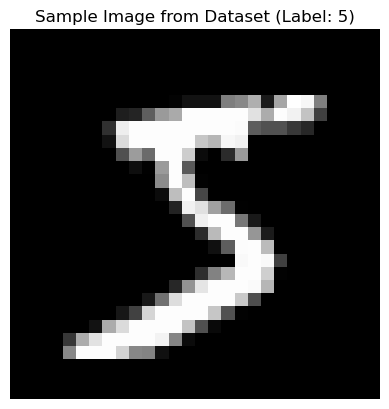

Data Shape: (60000, 28, 28)
Pixel Range: 0 to 255

Step 2: Preprocessing Data...

Step 3: Building CNN Feature Extractor...
Training CNN (Feature Learning)...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.9442 - loss: 0.1864 - val_accuracy: 0.9800 - val_loss: 0.0671
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9823 - loss: 0.0570 - val_accuracy: 0.9880 - val_loss: 0.0393
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9879 - loss: 0.0391 - val_accuracy: 0.9885 - val_loss: 0.0427
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9905 - loss: 0.0298 - val_accuracy: 0.9875 - val_loss: 0.0429
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9925 - loss: 0.0239 - val_accuracy: 0.9898 - val_loss: 0.0341

Step 4: Extracting Features...

Step 5: Parameter Study (SVM Kernel Comparison)...
Training Linear SVM...
--> Accuracy (Linear Kernel): 99.04%
Training RBF SVM (Non-linear)...
--> Accuracy (RBF K

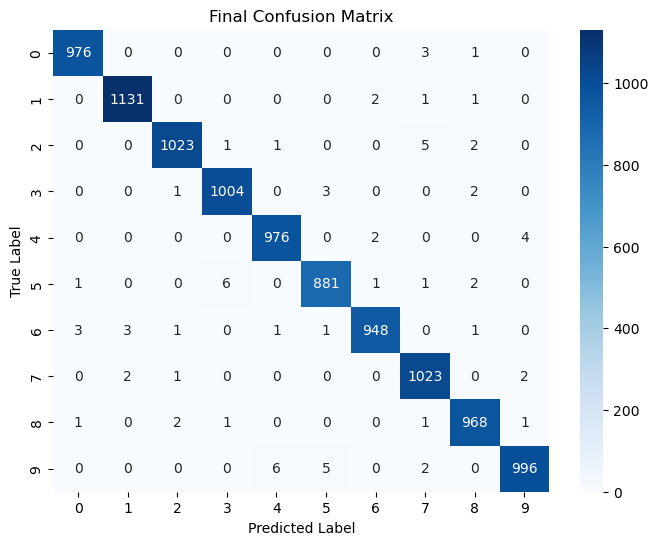

✅ Project Complete. Files saved successfully!


In [2]:
# ==========================================================
# MASTER PROJECT: Hybrid CNN-SVM for MNIST Classification
# Author: Pratik Mohanty
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import joblib

# ----------------------------------------------------------
# PART 1: EXPLORATORY DATA ANALYSIS (EDA)
# ----------------------------------------------------------
print("Step 1: Performing Exploratory Analysis...")
(train_X_raw, train_y_raw), (test_X_raw, test_y_raw) = mnist.load_data()

# 1. Plot Class Distribution (Fixed Warning)
plt.figure(figsize=(8, 4))
sns.countplot(x=train_y_raw, hue=train_y_raw, legend=False, palette="viridis")
plt.title("Exploratory Analysis: Class Balance")
plt.xlabel("Digit (0-9)")
plt.ylabel("Number of Samples")
plt.show()

# 2. Visual check of a sample image
plt.imshow(train_X_raw[0], cmap='gray')
plt.title(f"Sample Image from Dataset (Label: {train_y_raw[0]})")
plt.axis('off')
plt.show()

print(f"Data Shape: {train_X_raw.shape}")
print(f"Pixel Range: {train_X_raw.min()} to {train_X_raw.max()}")

# ----------------------------------------------------------
# PART 2: DATA PREPROCESSING
# ----------------------------------------------------------
print("\nStep 2: Preprocessing Data...")
# Normalize to 0-1 range and reshape for CNN
train_images = np.expand_dims(train_X_raw.astype('float32') / 255.0, -1)
test_images = np.expand_dims(test_X_raw.astype('float32') / 255.0, -1)
train_labels_cat = to_categorical(train_y_raw)

# ----------------------------------------------------------
# PART 3: BUILDING THE HYBRID CNN
# ----------------------------------------------------------
print("\nStep 3: Building CNN Feature Extractor...")
inputs = Input(shape=(28, 28, 1))

# Feature Extraction Layers (The "Eyes")
x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Flatten()(x)

# The "Bottleneck" Feature Layer
features = layers.Dense(64, activation='relu', name='feature_layer')(x)

# Temporary Output for Training
outputs = layers.Dense(10, activation='softmax')(features)

model = models.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train CNN
print("Training CNN (Feature Learning)...")
history = model.fit(train_images, train_labels_cat, epochs=5, batch_size=64, validation_split=0.1, verbose=1)

# ----------------------------------------------------------
# PART 4: FEATURE EXTRACTION
# ----------------------------------------------------------
print("\nStep 4: Extracting Features...")
feature_extractor = models.Model(inputs=model.input, outputs=model.get_layer('feature_layer').output)

X_train_features = feature_extractor.predict(train_images, verbose=0)
X_test_features = feature_extractor.predict(test_images, verbose=0)

# ----------------------------------------------------------
# PART 5: PARAMETER STUDY (CRITICAL DISCUSSION)
# ----------------------------------------------------------
print("\nStep 5: Parameter Study (SVM Kernel Comparison)...")

# Experiment A: Linear Kernel
print("Training Linear SVM...")
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_features, train_y_raw)
acc_linear = svm_linear.score(X_test_features, test_y_raw)
print(f"--> Accuracy (Linear Kernel): {acc_linear*100:.2f}%")

# Experiment B: RBF Kernel
print("Training RBF SVM (Non-linear)...")
svm_rbf = SVC(kernel='rbf', C=10)
svm_rbf.fit(X_train_features, train_y_raw)
acc_rbf = svm_rbf.score(X_test_features, test_y_raw)
print(f"--> Accuracy (RBF Kernel): {acc_rbf*100:.2f}%")

# Select the best one automatically
if acc_rbf > acc_linear:
    best_svm = svm_rbf
    print("Conclusion: RBF Kernel is better.")
else:
    best_svm = svm_linear
    print("Conclusion: Linear Kernel is better.")

# ----------------------------------------------------------
# PART 6: FINAL VISUALIZATION & SAVING
# ----------------------------------------------------------
print("\nStep 6: Saving Final Model...")

# Plot Confusion Matrix
preds = best_svm.predict(X_test_features)
cm = confusion_matrix(test_y_raw, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Final Confusion Matrix")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Save files for the App
feature_extractor.save('mnist_cnn_features.keras')
joblib.dump(best_svm, 'mnist_svm_classifier.pkl')
print("✅ Project Complete. Files saved successfully!")

In [ ]:
import tkinter as tk
from tkinter import messagebox
import numpy as np
import tensorflow as tf
import joblib
from PIL import Image, ImageDraw, ImageOps
from scipy.ndimage import center_of_mass
import math

# Load models
cnn = tf.keras.models.load_model('mnist_cnn_features.keras')
svm = joblib.load('mnist_svm_classifier.pkl')

class App:
    def __init__(self, root):
        self.root = root
        self.root.title("Smart AI Demo (Auto-Correct)")
        
        # Canvas
        self.canvas = tk.Canvas(root, width=280, height=280, bg='black')
        self.canvas.pack(pady=10)
        
        # Image memory
        self.image = Image.new("L", (280, 280), 0)
        self.draw = ImageDraw.Draw(self.image)
        self.canvas.bind("<B1-Motion>", self.paint)
        
        # Buttons
        btn_frame = tk.Frame(root)
        btn_frame.pack()
        tk.Button(btn_frame, text="PREDICT", command=self.predict, bg="green", fg="white", font=('Arial', 12)).pack(side=tk.LEFT, padx=10)
        tk.Button(btn_frame, text="CLEAR", command=self.clear, bg="red", fg="white", font=('Arial', 12)).pack(side=tk.LEFT, padx=10)
        
        self.label = tk.Label(root, text="Draw a digit...", font=("Arial", 16))
        self.label.pack(pady=10)

    def paint(self, event):
        # Increased brush size for better detection
        r = 14  
        x1, y1 = (event.x - r), (event.y - r)
        x2, y2 = (event.x + r), (event.y + r)
        self.canvas.create_oval(x1, y1, x2, y2, fill='white', outline='white')
        self.draw.ellipse([x1, y1, x2, y2], fill=255, outline=255)

    def clear(self):
        self.canvas.delete("all")
        self.image = Image.new("L", (280, 280), 0)
        self.draw = ImageDraw.Draw(self.image)
        self.label.config(text="Draw a digit...")

    def get_best_shift(self, img):
        # Function to center the image by mass
        cy, cx = center_of_mass(np.array(img))
        rows, cols = img.shape
        shiftx = np.round(cols/2.0-cx).astype(int)
        shifty = np.round(rows/2.0-cy).astype(int)
        return shiftx, shifty

    def shift(self, img, sx, sy):
        rows, cols = img.shape
        M = np.float32([[1, 0, sx], [0, 1, sy]])
        # We simulate the shift using slicing for simple numpy arrays
        shifted = np.roll(img, sx, axis=1)
        shifted = np.roll(shifted, sy, axis=0)
        return shifted

    def predict(self):
        # 1. Resize slightly larger first
        img = self.image.resize((28, 28), Image.Resampling.LANCZOS)
        
        # 2. Convert to numpy
        img_arr = np.array(img)
        
        # 3. SMART CENTERING (The Fix)
        # We calculate the "center of mass" and shift the image so the digit is in the middle
        try:
            cy, cx = center_of_mass(img_arr)
            rows, cols = img_arr.shape
            shiftx = np.round(cols/2.0-cx).astype(int)
            shifty = np.round(rows/2.0-cy).astype(int)
            
            # Apply shift
            # Using scipy or simple roll
            img_arr = np.roll(img_arr, shiftx, axis=1)
            img_arr = np.roll(img_arr, shifty, axis=0)
        except:
            pass # If image is empty, skip

        # 4. Normalize
        img_arr = img_arr.astype('float32') / 255.0
        img_arr = img_arr.reshape(1, 28, 28, 1)

        # 5. Predict
        features = cnn.predict(img_arr, verbose=0)
        prediction = svm.predict(features)[0]
        self.label.config(text=f"I think it is: {prediction}")

root = tk.Tk()
app = App(root)
root.mainloop()